In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score

In [2]:
df= pd.read_csv('ToyotaCorolla - MLR.csv')
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
df.shape

(1436, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [5]:
### checking duplicates
df.duplicated().sum()

np.int64(1)

In [6]:
df[df.duplicated()]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [7]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
### missing values
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [10]:
###outlier checking
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [11]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.0,1435.000000,1435.000000
mean,10720.915679,55.980488,68571.782578,101.491986,0.055749,1576.560976,4.032753,4.0,5.026481,1072.287108
std,3608.732978,18.563312,37491.094553,14.981408,0.229517,424.387533,0.952667,0.0,0.188575,52.251882
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,4.0,3.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.000000,3.000000,4.0,5.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,110.000000,0.000000,1600.000000,4.000000,4.0,5.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,110.000000,0.000000,1600.000000,5.000000,4.0,5.000000,1085.000000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.000000,5.000000,4.0,6.000000,1615.000000


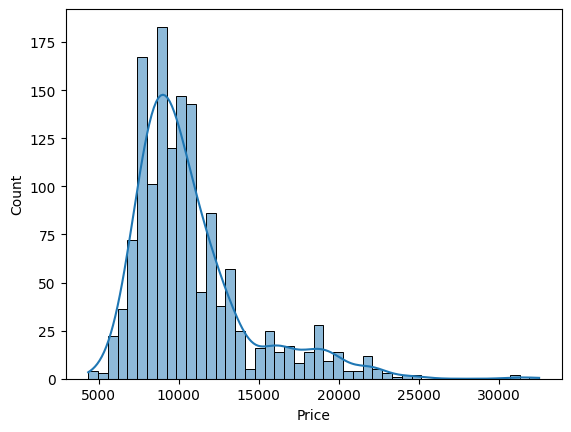

In [12]:
sns.histplot(df['Price'], kde=True)
plt.show()

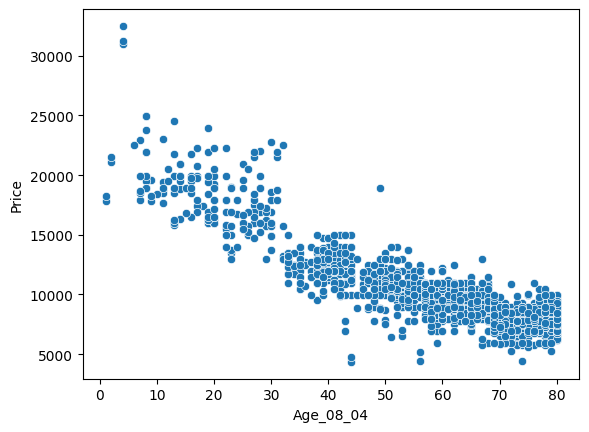

In [13]:
sns.scatterplot(x='Age_08_04', y='Price', data=df)
plt.show()

<Axes: xlabel='Fuel_Type', ylabel='count'>

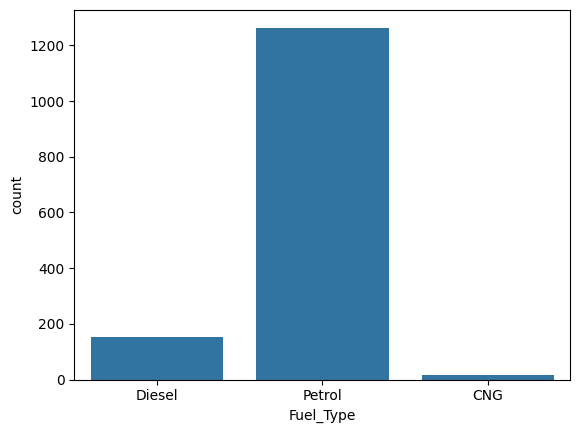

In [14]:
sns.countplot(x='Fuel_Type', data=df)

In [15]:
numerical_cols = df.select_dtypes(include=['int64']).columns

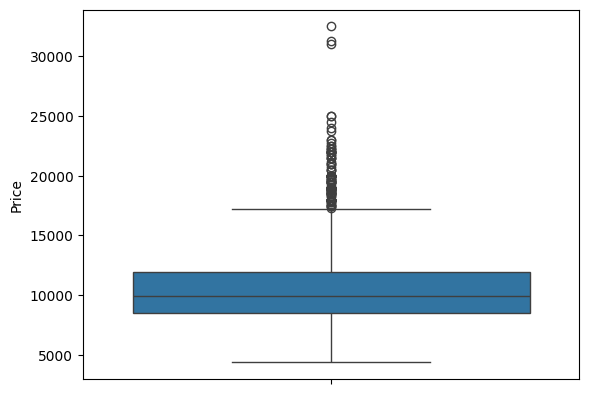

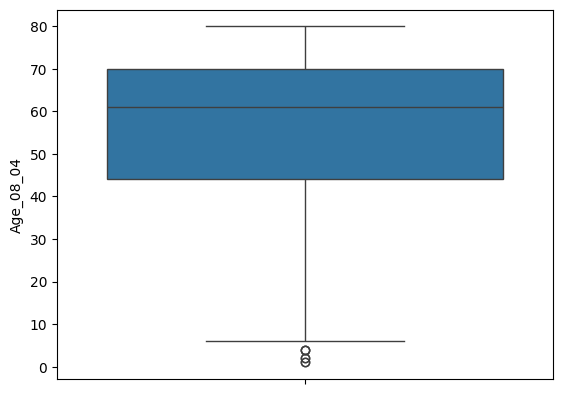

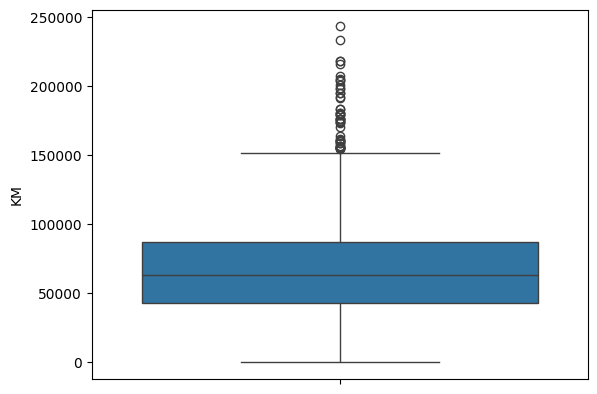

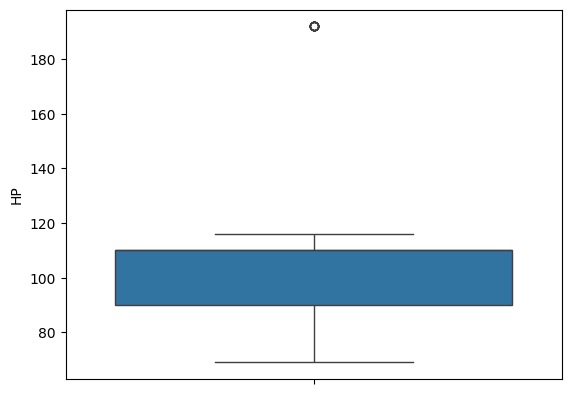

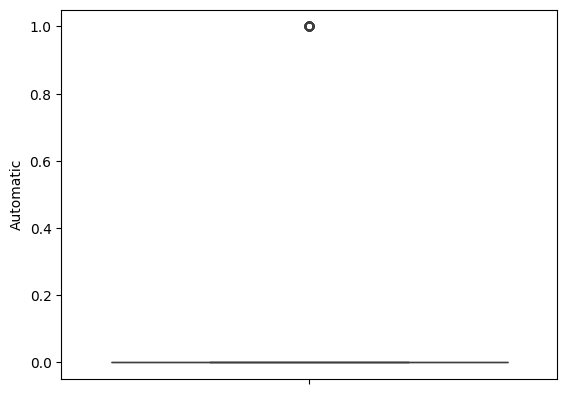

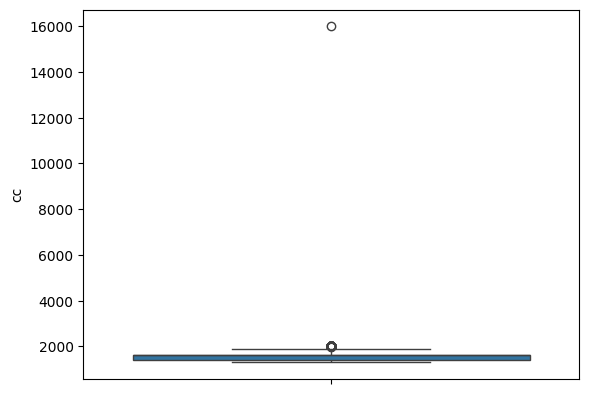

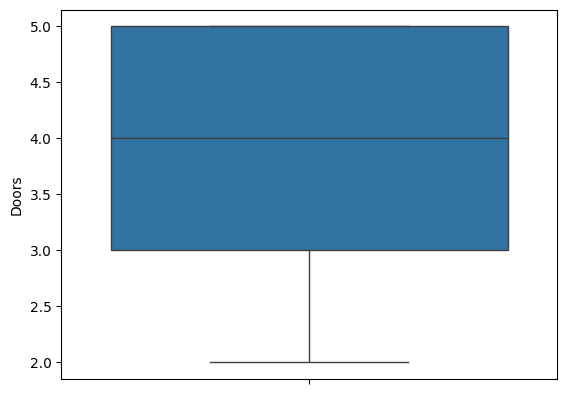

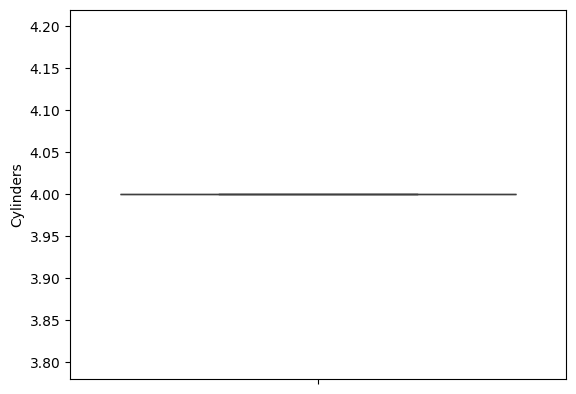

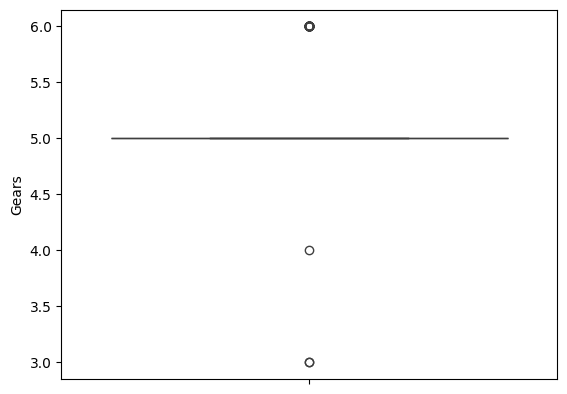

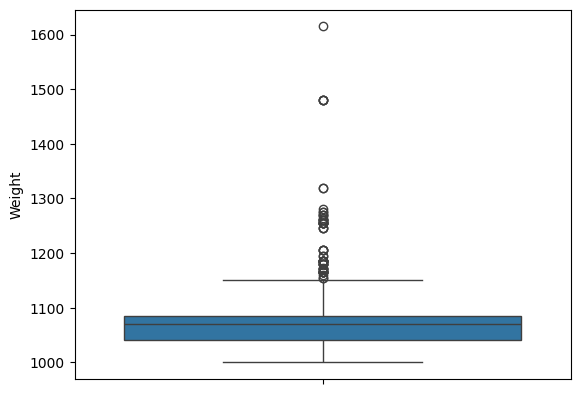

In [16]:
for col in numerical_cols:
    sns.boxplot(data=df,y=col)
    plt.show()

In [17]:
#### outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+ 1.5*IQR
    df[column]= df[column].apply(lambda x:lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int64']).columns:
    outlier_capping(df,col)

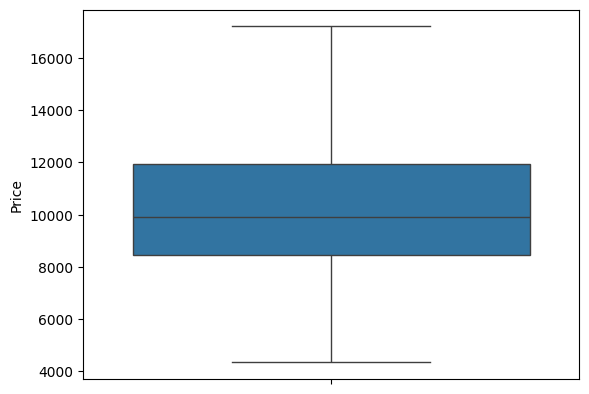

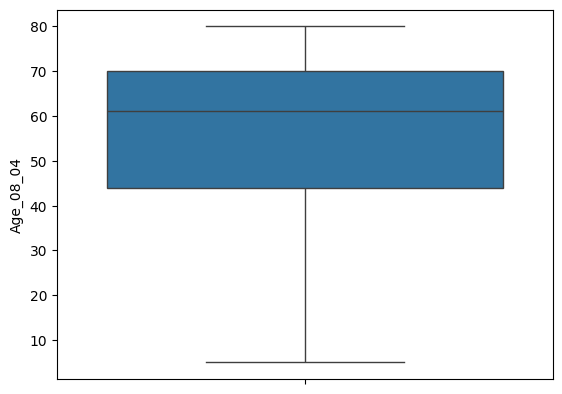

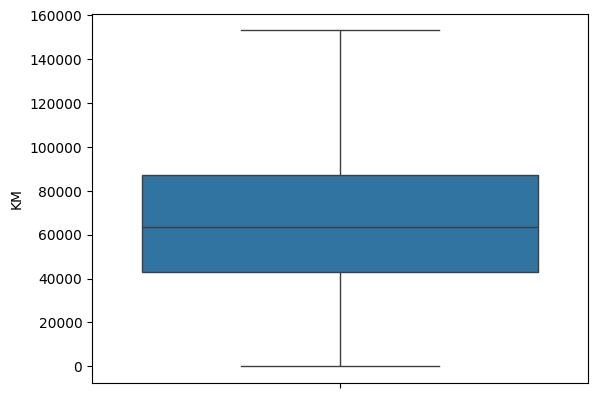

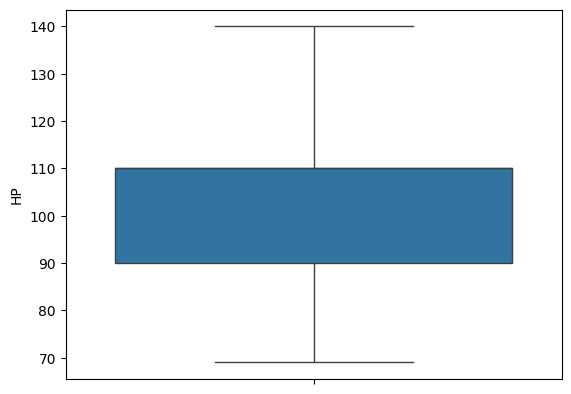

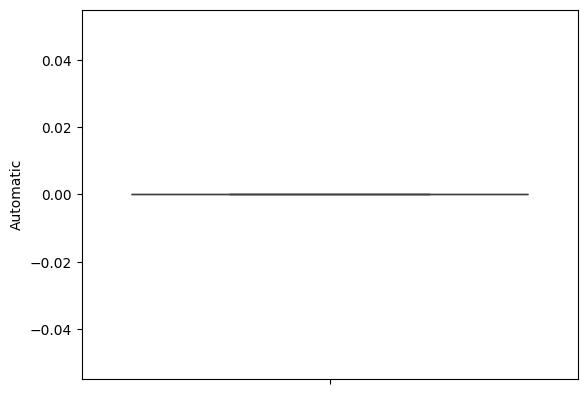

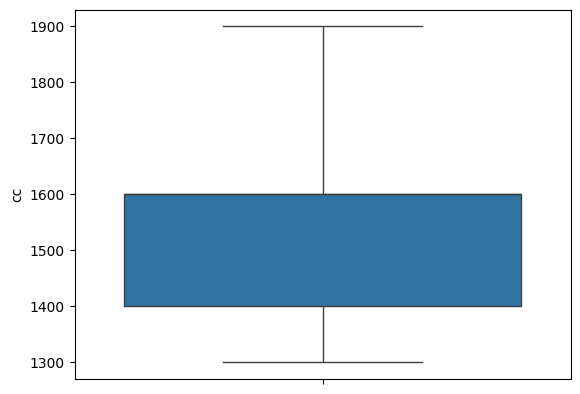

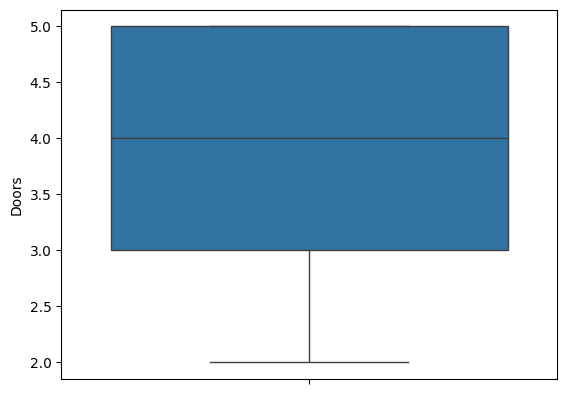

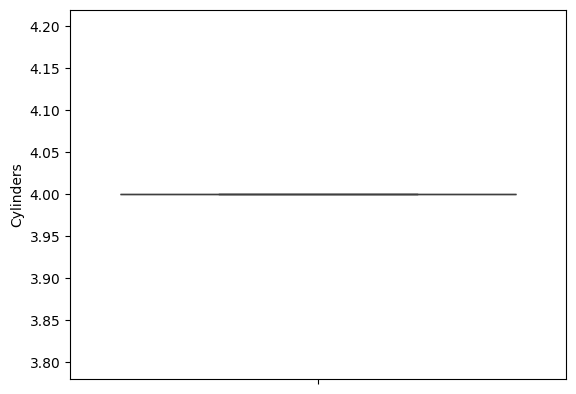

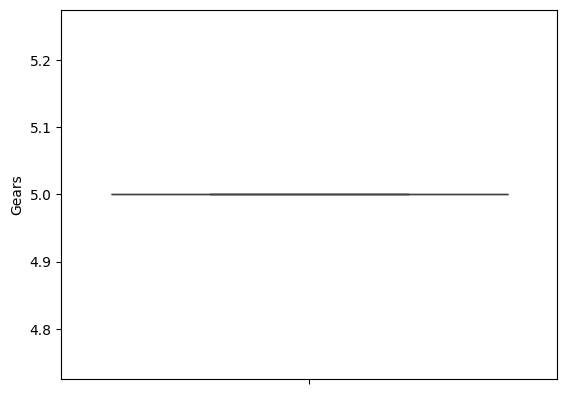

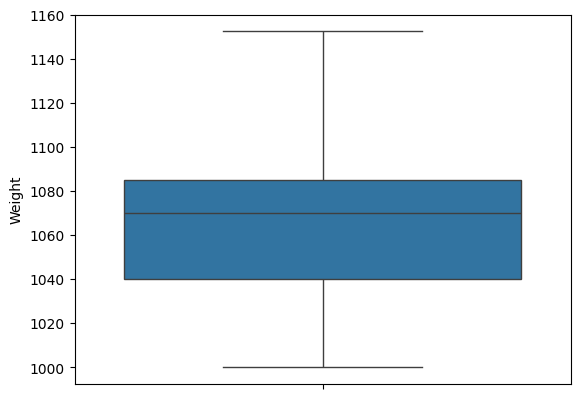

In [18]:
for col in numerical_cols:
    sns.boxplot(data=df,y=col)
    plt.show()

In [19]:
#### Feature Engineering

In [20]:
## for categrical column
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [21]:
### missing values
df.isnull().sum()

Price               0
Age_08_04           0
KM                  0
HP                  0
Automatic           0
cc                  0
Doors               0
Cylinders           0
Gears               0
Weight              0
Fuel_Type_Diesel    0
Fuel_Type_Petrol    0
dtype: int64

In [22]:
print(df.columns)

Index(['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol'],
      dtype='object')


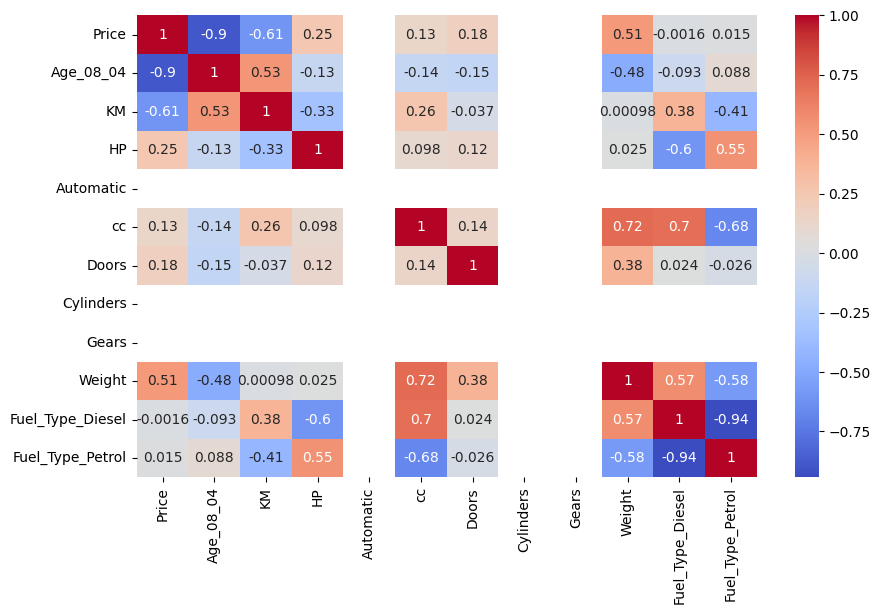

In [23]:
corr=df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [24]:
target = df[['Price']]
features = df.select_dtypes(include=['int64','float64'])
features = features.drop(columns=['Price'])

In [25]:
features.columns

Index(['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders',
       'Gears', 'Weight'],
      dtype='object')

<Axes: >

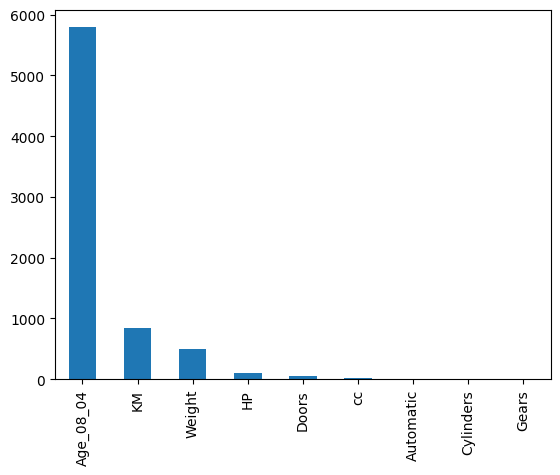

In [26]:
from sklearn.feature_selection import f_regression
f_reg=f_regression(features,target)
pd.Series(f_reg[0],index=features.columns).sort_values(ascending=False).plot(kind='bar')

### Variance Inflation Factor (VIF)¶

In [27]:
#### checking Multicolinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [28]:
features.values

array([[2.3000e+01, 4.6986e+04, 9.0000e+01, ..., 4.0000e+00, 5.0000e+00,
        1.1525e+03],
       [2.3000e+01, 7.2937e+04, 9.0000e+01, ..., 4.0000e+00, 5.0000e+00,
        1.1525e+03],
       [2.4000e+01, 4.1711e+04, 9.0000e+01, ..., 4.0000e+00, 5.0000e+00,
        1.1525e+03],
       ...,
       [7.1000e+01, 1.7016e+04, 8.6000e+01, ..., 4.0000e+00, 5.0000e+00,
        1.0150e+03],
       [7.0000e+01, 1.6916e+04, 8.6000e+01, ..., 4.0000e+00, 5.0000e+00,
        1.0150e+03],
       [7.6000e+01, 1.0000e+00, 1.1000e+02, ..., 4.0000e+00, 5.0000e+00,
        1.1140e+03]], shape=(1435, 9))

In [29]:
vif = pd.DataFrame()
vif["Feature"] = features.columns
vif["VIF"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]
print(vif)

     Feature       VIF
0  Age_08_04  2.114829
1         KM  1.920202
2         HP  1.253571
3  Automatic       NaN
4         cc  2.824547
5      Doors  1.283791
6  Cylinders  0.000000
7      Gears  0.000000
8     Weight  3.704059


In [30]:
features.drop(columns=['Cylinders','Gears'],inplace=True)
features.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Weight
0,23.0,46986.0,90.0,0.0,1900.0,3,1152.5
1,23.0,72937.0,90.0,0.0,1900.0,3,1152.5
2,24.0,41711.0,90.0,0.0,1900.0,3,1152.5
3,26.0,48000.0,90.0,0.0,1900.0,3,1152.5
4,30.0,38500.0,90.0,0.0,1900.0,3,1152.5


In [31]:
#### Scaling

In [32]:
features.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Weight
0,23.0,46986.0,90.0,0.0,1900.0,3,1152.5
1,23.0,72937.0,90.0,0.0,1900.0,3,1152.5
2,24.0,41711.0,90.0,0.0,1900.0,3,1152.5
3,26.0,48000.0,90.0,0.0,1900.0,3,1152.5
4,30.0,38500.0,90.0,0.0,1900.0,3,1152.5


In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
#### train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.80,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 7)
(287, 7)
(1148, 1)
(287, 1)


In [35]:
x_train.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Weight
108,20.0,7187.0,110.0,0.0,1600.0,3,1105.0
1279,78.0,73638.0,86.0,0.0,1300.0,4,1015.0
857,62.0,64797.0,110.0,0.0,1600.0,5,1075.0
902,65.0,59000.0,110.0,0.0,1600.0,5,1075.0
372,33.0,16512.0,97.0,0.0,1400.0,5,1085.0


In [36]:
std_sca=StandardScaler()
x_train[['Age_08_04','Weight','KM']]=std_sca.fit_transform(x_train[['Age_08_04','Weight','KM']])

In [37]:
x_train.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Weight
108,-1.940533,-1.748188,110.0,0.0,1600.0,3,0.954608
1279,1.182405,0.176456,86.0,0.0,1300.0,4,-1.387370
857,0.320905,-0.079609,110.0,0.0,1600.0,5,0.173948
902,0.482436,-0.247509,110.0,0.0,1600.0,5,0.173948
372,-1.240564,-1.478104,97.0,0.0,1400.0,5,0.434168


In [38]:
x_test[['Age_08_04','Weight','KM']]=std_sca.transform(x_test[['Age_08_04','Weight','KM']])

In [39]:
x_test.head()

,Age_08_04,KM,HP,Automatic,cc,Doors,Weight
57,-1.617470,-0.710923,97.0,0.0,1400.0,5,1.084718
1002,0.320905,-0.826777,110.0,0.0,1600.0,5,0.173948
360,-1.132876,-1.260908,97.0,0.0,1400.0,3,-1.127151
903,0.267061,-0.247509,110.0,0.0,1600.0,5,0.043838
1276,1.236249,0.189634,110.0,0.0,1600.0,5,0.173948


### Model 1

In [40]:
#### Model Training
lin_model= LinearRegression()
lin_model.fit(x_train,y_train)

LinearRegression()

In [41]:
lin_model.coef_

array([[-1.95552419e+03, -5.45846617e+02,  2.64810353e+01,
        -1.13686838e-12, -2.45717156e+00, -8.16564146e+01,
         9.46392899e+02]])

In [42]:
lin_model.intercept_

array([11969.93524714])

In [43]:
#### Training_Validation
y_pred= lin_model.predict(x_train)
r2_score(y_train,y_pred)

0.8675985105652546

In [44]:
#### Testing_Validation
y_pred1= lin_model.predict(x_test)
r2_score(y_test,y_pred1)

0.8473627877706419

<Axes: xlabel='Price'>

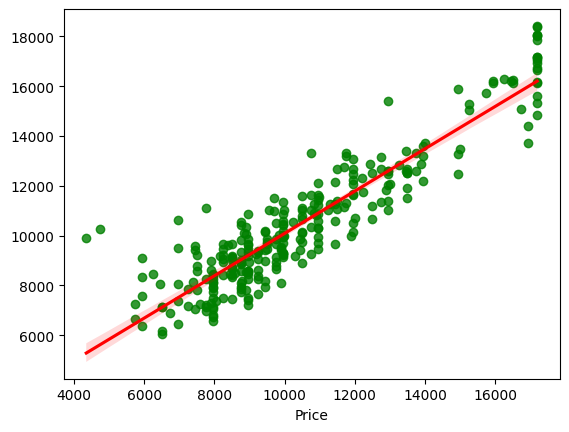

In [45]:
#### Regression Plot
sns.regplot(x=y_test,y=y_pred1,scatter_kws={'color':'green'},line_kws={'color':'red'})

### Error Metrics

In [46]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

In [47]:
##### mean_absolute_error
mean_absolute_error(y_test,y_pred1)

837.5200864916532

In [48]:
#### mean_squared_error
mean_squared_error(y_test,y_pred1)

1293397.7757883205

In [49]:
##### Mean_Absolute_Percentage_Error
mean_absolute_percentage_error(y_test,y_pred1)*100

9.035598171998876

In [50]:
##### Root Mean Squared Error
rmse= np.sqrt(mean_squared_error(y_test,y_pred1))
rmse

np.float64(1137.2764728896489)

In [51]:
r_squ=r2_score(y_test,y_pred1)
r_squ

0.8473627877706419

In [52]:
x_test.shape

(287, 7)

In [53]:
N=287
k=5

In [54]:
adj_Rsq= 1-(1-r_squ)*(N-1)/(N-k-1)
adj_Rsq

0.8446468231402262

## Model 2:

In [55]:
X2 = df[['Age_08_04','KM','HP','Weight']]
y=df['Price']
X_train2, X_test2, y_train2, y_test2 = train_test_split(
X2, y, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

In [56]:
print("Model 2 R2:", r2_score(y_test2, y_pred2))
print("Model 2 RMSE:", np.sqrt(mean_squared_error(y_test2, y_pred2)))

Model 2 R2: 0.8469228311341661
Model 2 RMSE: 1142.5766606357518


## Model3

In [57]:
model3 = LinearRegression()
model3.fit(x_train, y_train)

y_pred3 = model3.predict(x_test)

print("Model 3 R2:", r2_score(y_test, y_pred3))
print("Model 3 RMSE:", np.sqrt(mean_squared_error(y_test, y_pred3)))

Model 3 R2: 0.8473627877706419
Model 3 RMSE: 1137.2764728896489


# Ridge Regression

In [58]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)
y_pred_ridge = ridge.predict(x_test)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))

Ridge R2: 0.8473513262884783
Ridge RMSE: 1137.3191709615403


# Lasso Regression

In [59]:
lasso = Lasso(alpha=0.1)
lasso.fit(x_train, y_train)
y_pred_lasso = lasso.predict(x_test)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

Lasso R2: 0.8473641644676202
Lasso RMSE: 1137.271344098998


In [60]:
results = pd.DataFrame({
    'Model':['Linear Regression','Model 2','Model 3','Ridge','Lasso'],
    'R2 Score':[r2_score(y_test,y_pred1),
                r2_score(y_test2,y_pred2),
                r2_score(y_test,y_pred3),
                r2_score(y_test,y_pred_ridge),
                r2_score(y_test,y_pred_lasso)]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.847363
1            Model 2  0.846923
2            Model 3  0.847363
3              Ridge  0.847351
4              Lasso  0.847364


#### Interpretation:
All models have almost the same R² score (~0.847)

#### Assumptions Made in This Analysis

#### Implications

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor